# Compresión de modelos basados en ML

### Imports

In [156]:
import os
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.models import *
from keras.layers import *
from keras.utils import to_categorical
from keras.optimizers import SGD, Adam
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

## Quantization
from qkeras import *

## Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist

from distillationClassKeras import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [157]:
fig_path = './figs/MNIST'

models_dir = '/Users/denisegayet/Documents/Cursos/UNMDP/ml_fpga_unmdp/labs/lab1/models/' 
model = load_model(models_dir+'mnistModel_FC_vanilla.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 219818 (858.66 KB)
Trainable params: 219818 (858.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
# dataset loading
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

w = x_train_norm.shape[1]
h = x_train_norm.shape[2]

# classes
n_classes = 10

model= Sequential([

    Flatten(input_shape=(w, h)),
    Dense(20, activation='relu'),
    Dense(n_classes, activation='softmax')

])

In [8]:
classes, counts = np.unique(y_train, return_counts=True)
n_classes = len(classes)
in_shape = (x_train_norm.shape[1], x_train_norm.shape[2])

print(f"\nDataset input shape: {in_shape}")
print(f"\nOutput classes: {n_classes}")

# one-hot encode labels
y_train_sparse = y_train.copy()
y_train = to_categorical(y_train, num_classes = n_classes)
y_test = to_categorical(y_test, num_classes = n_classes)



Dataset input shape: (28, 28)

Output classes: 10


## Prunning

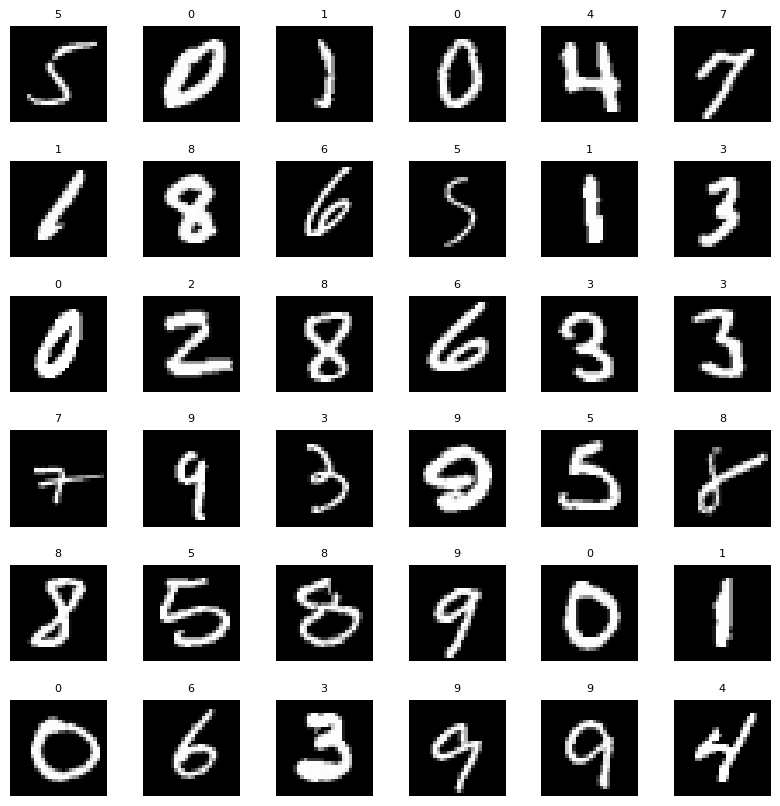

In [9]:
# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train_norm) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train_norm[index], cmap='gray')
    label_index = int(y_train_sparse[index])
    axes[i].set_title(label_index, fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [10]:
hparams = {
    'epochs': 50,
    'learning-rate': 0.001,
    'batch-size': 64,
    'val-split': 0.2,
    'loss': 'categorical_crossentropy'
}

op = Adam(hparams['learning-rate'])
final_sparsity = 0.3



In [11]:
model.compile(optimizer=op, loss=hparams['loss'], metrics=['accuracy'])
history_og = model.fit(
                    x_train_norm, y_train,
                    validation_split=hparams['val-split'],
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch-size'],
                    
)

Epoch 1/50
750/750 [==============================] - 1s 672us/step - loss: 0.5566 - accuracy: 0.8440 - val_loss: 0.2863 - val_accuracy: 0.9193
Epoch 2/50
750/750 [==============================] - 0s 554us/step - loss: 0.2678 - accuracy: 0.9237 - val_loss: 0.2356 - val_accuracy: 0.9344
Epoch 3/50
750/750 [==============================] - 0s 547us/step - loss: 0.2239 - accuracy: 0.9352 - val_loss: 0.2088 - val_accuracy: 0.9424
Epoch 4/50
750/750 [==============================] - 0s 539us/step - loss: 0.1992 - accuracy: 0.9426 - val_loss: 0.1950 - val_accuracy: 0.9446
Epoch 5/50
750/750 [==============================] - 0s 540us/step - loss: 0.1814 - accuracy: 0.9476 - val_loss: 0.1869 - val_accuracy: 0.9461
Epoch 6/50
750/750 [==============================] - 0s 568us/step - loss: 0.1668 - accuracy: 0.9512 - val_loss: 0.1760 - val_accuracy: 0.9514
Epoch 7/50
750/750 [==============================] - 0s 565us/step - loss: 0.1554 - accuracy: 0.9552 - val_loss: 0.1698 - val_accuracy:

In [38]:
pruning_params={
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=3000
    )
}

In [39]:
modelP = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)
modelP.compile(optimizer=op, loss=hparams['loss'], metrics=['accuracy'])

In [40]:
history = modelP.fit(
                    x_train_norm, y_train,
                    validation_split=hparams['val-split'],
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch-size'],
                    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
                    verbose=1
)

Epoch 1/50
750/750 [==============================] - 1s 771us/step - loss: 0.0497 - accuracy: 0.9847 - val_loss: 0.1854 - val_accuracy: 0.9553
Epoch 2/50
750/750 [==============================] - 0s 639us/step - loss: 0.0508 - accuracy: 0.9839 - val_loss: 0.1800 - val_accuracy: 0.9564
Epoch 3/50
750/750 [==============================] - 1s 696us/step - loss: 0.0511 - accuracy: 0.9843 - val_loss: 0.1811 - val_accuracy: 0.9558
Epoch 4/50
750/750 [==============================] - 1s 670us/step - loss: 0.0484 - accuracy: 0.9851 - val_loss: 0.1792 - val_accuracy: 0.9555
Epoch 5/50
750/750 [==============================] - 0s 619us/step - loss: 0.0462 - accuracy: 0.9863 - val_loss: 0.1841 - val_accuracy: 0.9543
Epoch 6/50
750/750 [==============================] - 0s 617us/step - loss: 0.0446 - accuracy: 0.9865 - val_loss: 0.1881 - val_accuracy: 0.9542
Epoch 7/50
750/750 [==============================] - 1s 669us/step - loss: 0.0435 - accuracy: 0.9874 - val_loss: 0.1837 - val_accuracy:

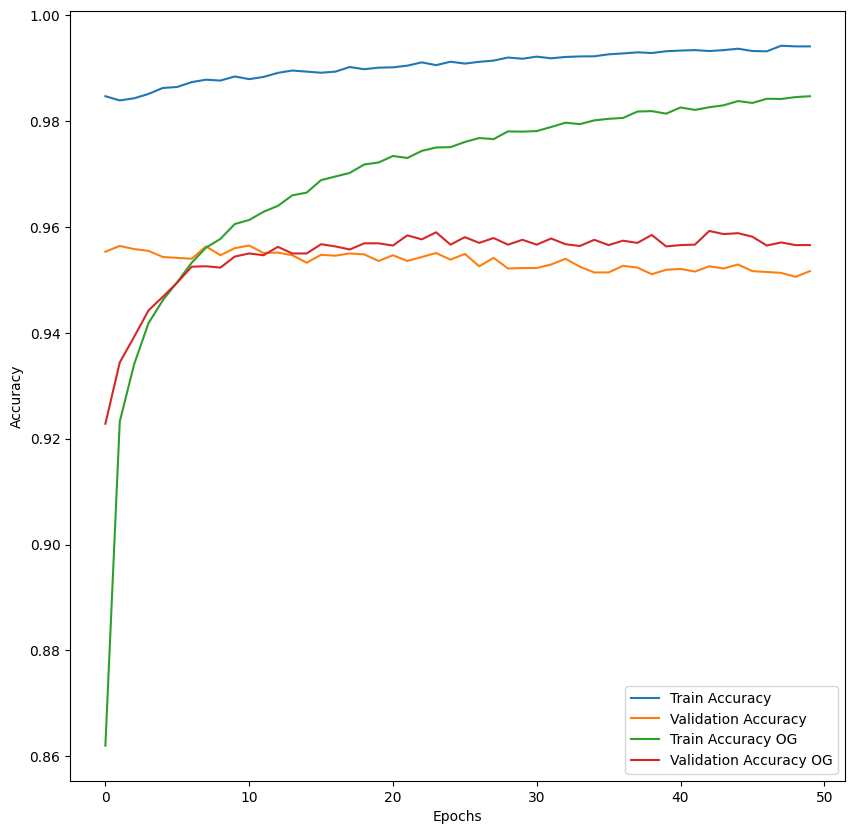

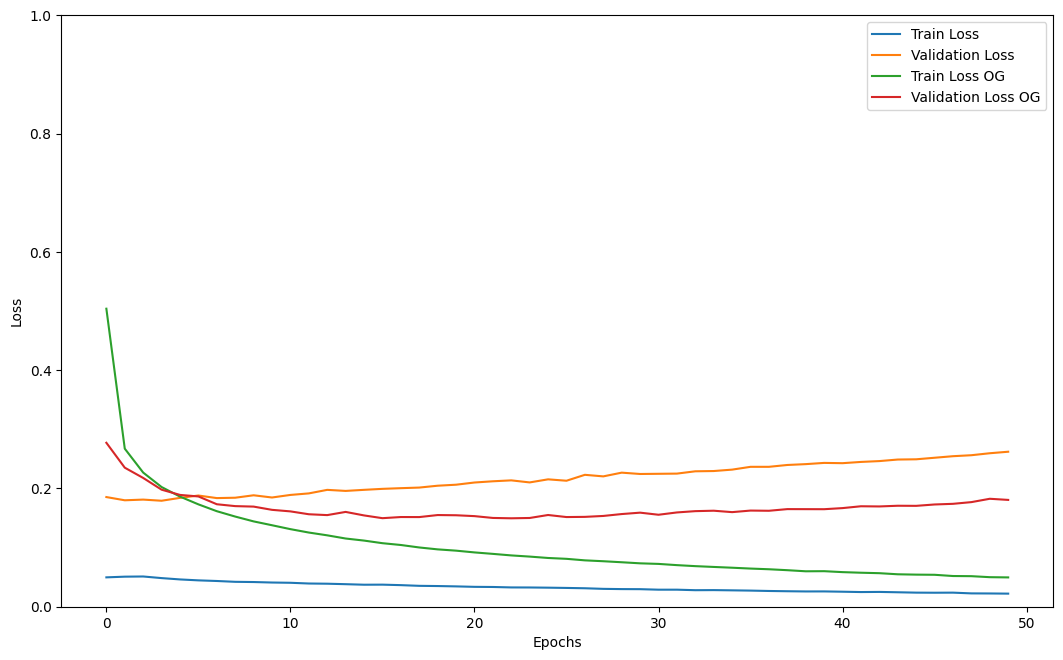

In [41]:
# Plot accuracy over epochs
fig_path = './figs/MNIST'


plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_og.history['accuracy'], label='Train Accuracy OG')
plt.plot(history_og.history['val_accuracy'], label='Validation Accuracy OG')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(10,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history_og.history['loss'], label='Train Loss OG')
plt.plot(history_og.history['val_loss'], label='Validation Loss OG')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,1)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi,768/fig.dpi)
plt.show()


In [42]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 20)                15700     
                                                                 
 dense_5 (Dense)             (None, 10)                210       
                                                                 
Total params: 15,910
Trainable params: 15,910
Non-trainable params: 0
_________________________________________________________________


In [43]:
modelP.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_flatten  (None, 784)              1         
 _2 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_4  (None, 20)               31382     
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_dense_5  (None, 10)               412       
  (PruneLowMagnitude)                                            
                                                                 
Total params: 31,795
Trainable params: 15,910
Non-trainable params: 15,885
_________________________________________________________________


313/313 [==============================] - 0s 303us/step


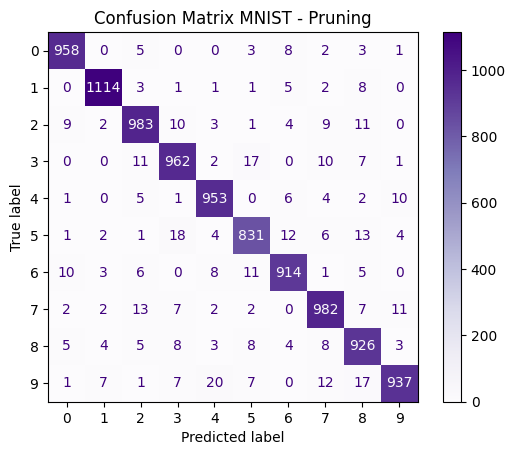

313/313 [==============================] - 0s 340us/step


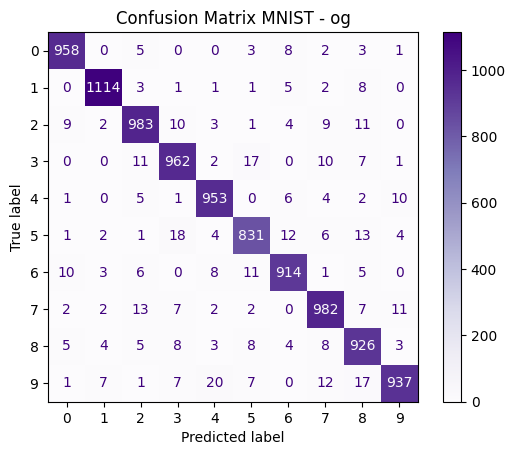

In [50]:
y_pred_probs = modelP.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()


y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - og')
plt.show()

In [51]:
modelP = strip_pruning(modelP)
modelP.save('models/mnistModel_FC_P.h5')


####  📝 Ejercicio: 

- Modificar el valor de final_sparsity (0.1, 0.3, 0.5, 0.7, 0.9) y reportar las métricas para cada modelo. Qué conclusión se puede obtener al respecto? 


--- 

A medida que se aumenta el valor de final_sparsity, se aumenta la cantidad de neuronas que se quitan del modelo. Por lo tanto, a mayor final_sparsity, pero es el rendimiento de la red. Con valores pequeños como 0.1 o 0.3, la red puede recuperarse de la perdida de neuronas y mantener el rendimiento. Sin embargo, para valores altos como 0.7 o 0.9, la red pierde capacidad de aprender y reduce su accuracy, dado que es una arquitectura mucho menor.

## Quantization

### QAT: Quantization Aware-Training

Se entrena desde 0 con cuantización (no con el modelo en precisión completa, es decir, fp de 32 bits)

In [33]:
# Estrategia de cuantizacion

# Definicion del numer de bits para kernel, bias, y activacion. 
# 8 bits

m = 8
d = 4

kernelQ = f'quantized_bits({m},{d},alpha=1)'
biasQ = f'quantized_bits({m},{d},alpha=1)'
activationQ = f'quantized_bits({m},{d})'

modelQAT = Sequential([
    Flatten(input_shape=(in_shape)),
    # QDense(100, name='fc1',
    #                     kernel_quantizer= kernelQ, bias_quantizer= biasQ,
    #                     kernel_initializer='lecun_uniform'),
    # QActivation(activation= activationQ ,  name='relu1'),


#     QDense(50, name='fc2',
#             kernel_quantizer=kernelQ, bias_quantizer=biasQ,
#             kernel_initializer='lecun_uniform'),
#     QActivation(activation=activationQ, name='relu2'), 
#     Dropout(0.1),
    

    QDense(20, name='fc3',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform'),
    QActivation(activation=activationQ, name='relu3'), 
    
    Dropout(0.1),
    
    QDense(10, name='output',
            kernel_quantizer= kernelQ, bias_quantizer= biasQ,
            kernel_initializer='lecun_uniform'),
    Activation(activation='softmax', name='softmax')
],
name="quantizedModel",
)

/Users/denisegayet/.venv_py39/lib/python3.9/site-packages/keras/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [34]:
modelQAT.summary()

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_8 (Flatten)         (None, 784)               0         
                                                                 
 fc3 (QDense)                (None, 20)                15700     
                                                                 
 relu3 (QActivation)         (None, 20)                0         
                                                                 
 dropout_9 (Dropout)         (None, 20)                0         
                                                                 
 output (QDense)             (None, 10)                210       
                                                                 
 softmax (Activation)        (None, 10)                0         
                                                                 
Total params: 15,910
Trainable params: 15,910
Non-tr

In [35]:
hparams={
    'epochs': 16,
    'learning_rate': 0.001,
    'batch_size': 64,
    'val_split' : 0.2,
    'loss' : 'categorical_crossentropy'
}

op = Adam(hparams['learning_rate'])
metrics = ['accuracy']


modelQAT.compile(optimizer=op, loss=hparams['loss'], metrics=metrics)
                
historyQAT = modelQAT.fit(x_train_norm, y_train,
                validation_split = hparams['val_split'],
                epochs=hparams['epochs'],
                batch_size = hparams['batch_size'],
                verbose=1
                )

Epoch 1/16
750/750 [==============================] - 5s 6ms/step - loss: 1.7810 - accuracy: 0.5997 - val_loss: 0.6595 - val_accuracy: 0.7960
Epoch 2/16
750/750 [==============================] - 2s 3ms/step - loss: 0.7142 - accuracy: 0.7821 - val_loss: 0.5268 - val_accuracy: 0.8472
Epoch 3/16
750/750 [==============================] - 1s 2ms/step - loss: 0.6104 - accuracy: 0.8149 - val_loss: 0.4622 - val_accuracy: 0.8618
Epoch 4/16
750/750 [==============================] - 1s 1ms/step - loss: 0.5595 - accuracy: 0.8340 - val_loss: 0.4619 - val_accuracy: 0.8652
Epoch 5/16
750/750 [==============================] - 2s 2ms/step - loss: 0.5201 - accuracy: 0.8480 - val_loss: 0.4364 - val_accuracy: 0.8747
Epoch 6/16
750/750 [==============================] - 2s 2ms/step - loss: 0.5000 - accuracy: 0.8549 - val_loss: 0.3934 - val_accuracy: 0.8857
Epoch 7/16
750/750 [==============================] - 1s 2ms/step - loss: 0.4757 - accuracy: 0.8621 - val_loss: 0.4226 - val_accuracy: 0.8798
Epoch 

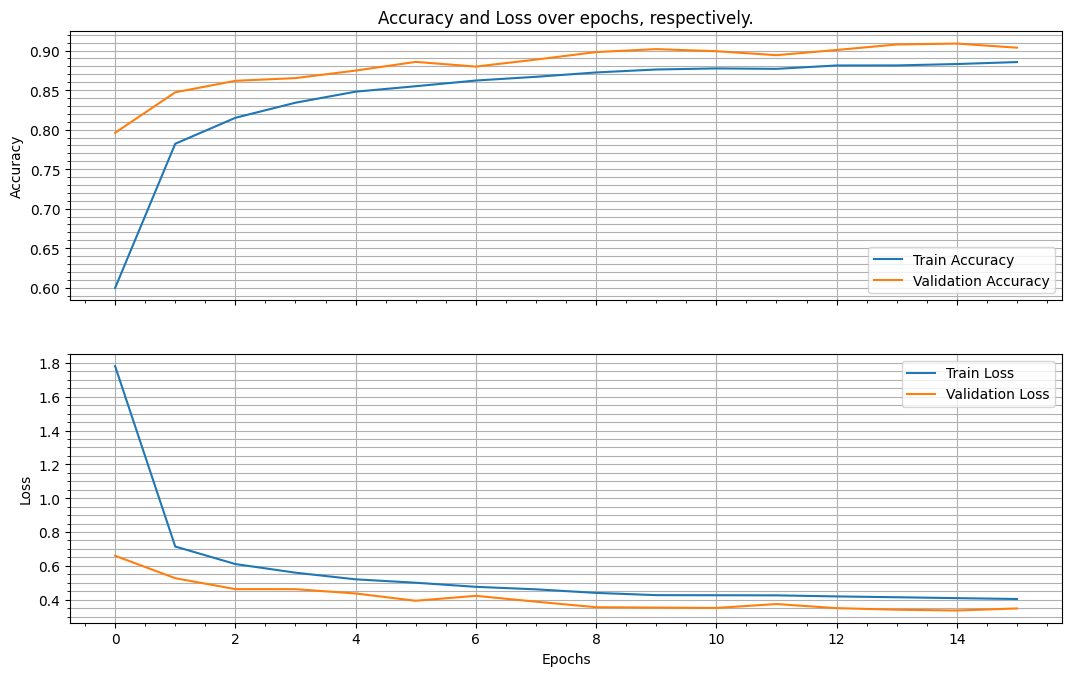

In [36]:
# Plot accuracy over epochs
fig_path = './figs/MNIST'

# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyQAT.history['accuracy'], label='Train Accuracy')
ax1.plot(historyQAT.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyQAT.history['loss'], label='Train Loss')
ax2.plot(historyQAT.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAT_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

### Metricas

313/313 [==============================] - 0s 629us/step


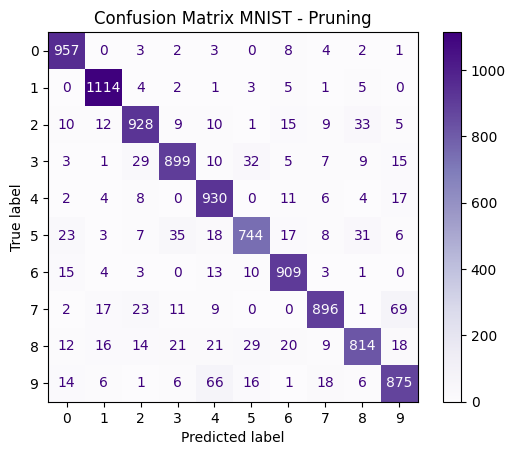

In [37]:
y_pred_probs = modelQAT.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()

## Quantization-aware prunning

Quantization-aware pruning (QAP) combina pruning con quantization-aware training. El objetivo es reducir el tamaño del modelo luego de cuantizarlo, para obtener una red más eficiente sin sacrificar precisión.

In [38]:
final_sparsity = 0.3

pruning_params = {
                'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=0, final_sparsity=final_sparsity, begin_step=0, end_step=3000
                )
            }

In [39]:
## Estrategia de cuantización

## Definición del número de bits para kernel, bias, y activación.
# 8-bits

kernelQ = "quantized_bits(8,4,alpha=1)"
biasQ = "quantized_bits(8, 4,alpha=1)"
activationQ = 'quantized_bits(8, 4)'

modelQ = Sequential(
            [   
                Flatten(input_shape=(28, 28)),
                # QDense(100, name='fc1',
                #         kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                #         kernel_initializer='lecun_uniform'),
                # QActivation(activation= activationQ ,  name='relu1'),

                # Dropout(0.1),

                # QDense(50, name='fc2',
                #         kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                #         kernel_initializer='lecun_uniform'),
                # QActivation(activation=activationQ, name='relu2'), 
                # Dropout(0.1),
                

                QDense(20, name='fc3',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu3'), 
                
                Dropout(0.1),
                
                QDense(10, name='output',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
                Activation(activation='softmax', name='softmax')
               
            ],

            name="quantizedModel",
        )

/Users/denisegayet/.venv_py39/lib/python3.9/site-packages/keras/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [40]:
# Entrenamiento


epochs = 16
lr = 0.001
loss = 'categorical_crossentropy'
op = Adam(lr)
metrics = ['accuracy']
batch = 64
val_split = 0.2


modelQAP = tfmot.sparsity.keras.prune_low_magnitude(modelQ, **pruning_params)

modelQAP.compile(optimizer=op, loss=loss, metrics=metrics)
                
historyQAP = modelQAP.fit(x_train_norm, y_train,
                validation_split = val_split,
                epochs=epochs,
                batch_size = batch,
                callbacks = [tfmot.sparsity.keras.UpdatePruningStep()],
                verbose=1
                )

Epoch 1/16
750/750 [==============================] - 7s 6ms/step - loss: 2.5294 - accuracy: 0.5346 - val_loss: 0.7157 - val_accuracy: 0.7873
Epoch 2/16
750/750 [==============================] - 2s 3ms/step - loss: 0.7688 - accuracy: 0.7655 - val_loss: 0.5397 - val_accuracy: 0.8379
Epoch 3/16
750/750 [==============================] - 2s 2ms/step - loss: 0.6353 - accuracy: 0.8073 - val_loss: 0.4643 - val_accuracy: 0.8605
Epoch 4/16
750/750 [==============================] - 2s 2ms/step - loss: 0.5769 - accuracy: 0.8281 - val_loss: 0.4433 - val_accuracy: 0.8722
Epoch 5/16
750/750 [==============================] - 1s 2ms/step - loss: 0.5425 - accuracy: 0.8397 - val_loss: 0.4125 - val_accuracy: 0.8851
Epoch 6/16
750/750 [==============================] - 1s 1ms/step - loss: 0.5161 - accuracy: 0.8490 - val_loss: 0.3979 - val_accuracy: 0.8829
Epoch 7/16
750/750 [==============================] - 1s 1ms/step - loss: 0.4894 - accuracy: 0.8560 - val_loss: 0.3927 - val_accuracy: 0.8888
Epoch 

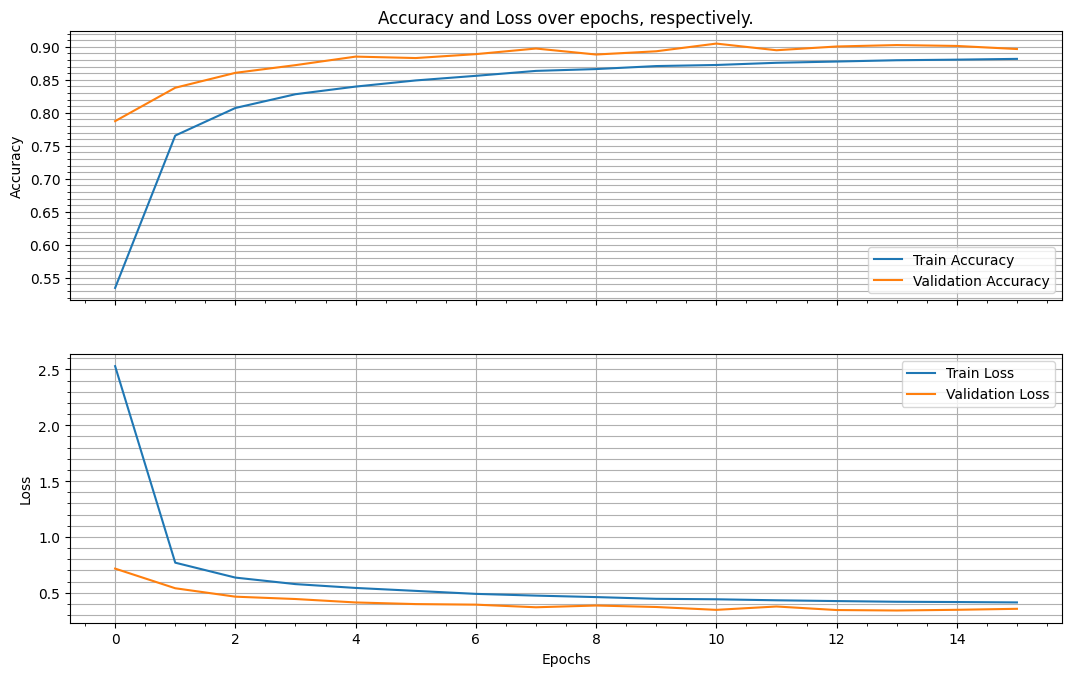

In [41]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyQAP.history['accuracy'], label='Train Accuracy')
ax1.plot(historyQAP.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyQAP.history['loss'], label='Train Loss')
ax2.plot(historyQAP.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

313/313 [==============================] - 0s 465us/step


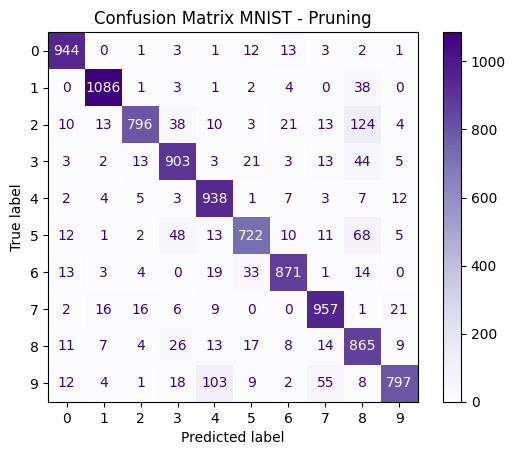

In [42]:
## metrics

y_pred_probs = modelQAP.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Confusion Matrix MNIST - Pruning')
plt.show()


#### 📝 Ejercicio: 

- Modificar el numero de bits (4, 8, 16, 32) y reportar las metricas de cada modelo, considerando QAT y QAP. Que conclusion puede obtener? 

- Modificar la arquitectura MLP (aumentando o disminuyendo capas) y reemplazando la capa _Flatten_ por _Dense_ . 

---

A mayor precisión, mejor accuracy, no hay tantos saltos en el loss porque al tener mejor precisión, los saltos de los pesos es menor.

## Knowledge Distillation

In [54]:
# Cargar dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0            # Normalización

x_train = x_train.reshape(-1, 28 * 28)                       # Aplanar imágenes
x_test = x_test.reshape(-1, 28 * 28)

y_train = to_categorical(y_train, num_classes=10, dtype=int)
y_test = to_categorical(y_test, num_classes=10, dtype=int)

In [ ]:
def build_teacher():
    model = keras.Sequential([
        Dense(512, activation="relu", input_shape=(28 * 28,)),
        Dense(256, activation="relu"),
        Dense(10,  activation="softmax")  
    ])
    return model

In [56]:
# Definir el modelo Teacher (MLP grande) 
hparamsT = {
    'batch-size' : 128,
    'epochs' : 16,
    'learning-rate' : 0.001
}



# Compilar y entrenar el modelo Teacher
teacher = build_teacher()
teacher.summary()

teacher.compile(optimizer="adam", 
                loss="categorical_crossentropy", 
                metrics=["accuracy"])
historyT = teacher.fit(x_train, y_train,
                       epochs=hparamsT['epochs'],
                       batch_size=hparamsT['batch-size'],
                       validation_data=(x_test, y_test))

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 512)               401920    
                                                                 
 dense_15 (Dense)            (None, 256)               131328    
                                                                 
 dense_16 (Dense)            (None, 10)                2570      
                                                                 
Total params: 535,818
Trainable params: 535,818
Non-trainable params: 0
_________________________________________________________________
Epoch 1/16
469/469 [==============================] - 6s 13ms/step - loss: 0.2253 - accuracy: 0.9341 - val_loss: 0.1077 - val_accuracy: 0.9645
Epoch 2/16
469/469 [==============================] - 7s 14ms/step - loss: 0.0818 - accuracy: 0.9751 - val_loss: 0.0851 - val_accuracy: 0.9737
Epoch 3/16
469/469 [======

In [104]:
# Definir el modelo Student (MLP más pequeño)
def build_student():
    model = keras.Sequential([
        Dense(64, activation="relu", input_shape=(28 * 28,)),  
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        
        Dense(10, activation="softmax")  # Softmax en la salida
    ])
    return model

student = build_student()

In [105]:
train_labels = np.argmax(y_train, axis=1)

distilledMLP = Distiller(student=student, teacher=teacher)

In [106]:
distilledMLP.student.summary()

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_103 (Dense)           (None, 64)                50240     
                                                                 
 dense_104 (Dense)           (None, 64)                4160      
                                                                 
 dense_105 (Dense)           (None, 64)                4160      
                                                                 
 dense_106 (Dense)           (None, 10)                650       
                                                                 
Total params: 59,210
Trainable params: 59,210
Non-trainable params: 0
_________________________________________________________________


In [107]:
hparamsS = {
    'epochs' : 32,
    'batch-size' : 64,
    'learning-rate' : 0.0001,
    'val-split' : 0.2,
}

adam = Adam(hparamsS['learning-rate'])
distilledMLP.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

historyS = distilledMLP.fit(x_train, train_labels, 
                           validation_split=hparamsS['val-split'],
                           batch_size = hparamsS['batch-size'], 
                           epochs= hparamsS['epochs'])

Epoch 1/32
750/750 [==============================] - 6s 7ms/step - sparse_categorical_accuracy: 0.7473 - student_loss: 0.9489 - distillation_loss: 2.1386e-04 - val_sparse_categorical_accuracy: 0.9006 - val_student_loss: 0.2291
Epoch 2/32
750/750 [==============================] - 3s 5ms/step - sparse_categorical_accuracy: 0.9032 - student_loss: 0.3392 - distillation_loss: 7.7378e-05 - val_sparse_categorical_accuracy: 0.9213 - val_student_loss: 0.1372
Epoch 3/32
750/750 [==============================] - 4s 5ms/step - sparse_categorical_accuracy: 0.9209 - student_loss: 0.2752 - distillation_loss: 6.2526e-05 - val_sparse_categorical_accuracy: 0.9308 - val_student_loss: 0.1269
Epoch 4/32
750/750 [==============================] - 4s 5ms/step - sparse_categorical_accuracy: 0.9321 - student_loss: 0.2387 - distillation_loss: 5.4122e-05 - val_sparse_categorical_accuracy: 0.9365 - val_student_loss: 0.0877
Epoch 5/32
750/750 [==============================] - 4s 5ms/step - sparse_categorical_a

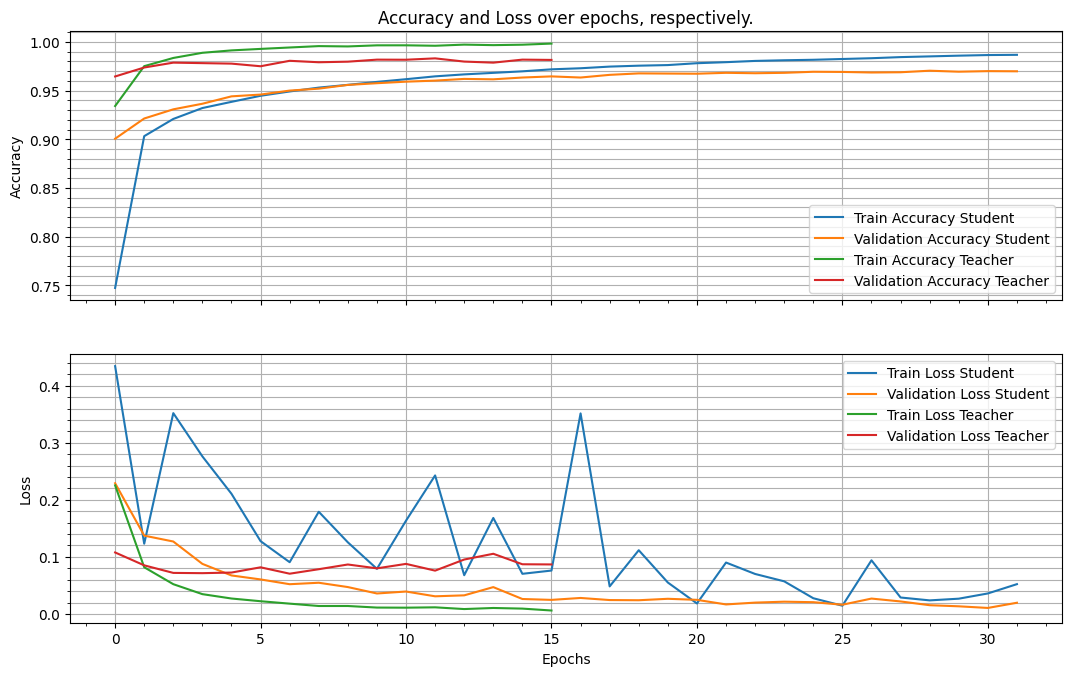

In [108]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyS.history['sparse_categorical_accuracy'], label='Train Accuracy Student')
ax1.plot(historyS.history['val_sparse_categorical_accuracy'], label='Validation Accuracy Student')
ax1.plot(historyT.history['accuracy'], label='Train Accuracy Teacher')
ax1.plot(historyT.history['val_accuracy'], label='Validation Accuracy Teacher')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyS.history['student_loss'], label='Train Loss Student')
ax2.plot(historyS.history['val_student_loss'], label='Validation Loss Student')
ax2.plot(historyT.history['loss'], label='Train Loss Teacher')
ax2.plot(historyT.history['val_loss'], label='Validation Loss Teacher')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

313/313 [==============================] - 0s 264us/step


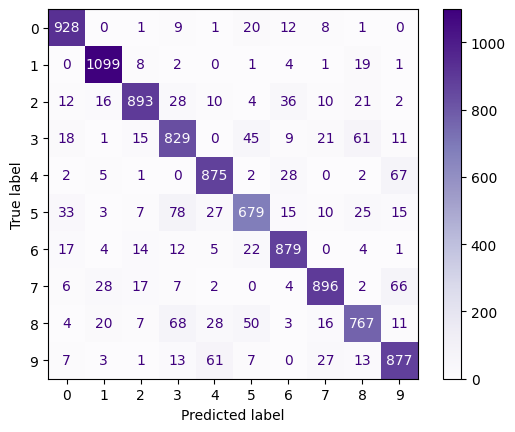

In [101]:
#### Métricas
y_pred_probs = distilledMLP.student.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is one-hot encoded, you need to convert it back to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.show()


### Conclusiones

Con el 10% de los pesos del Teacher, el Student consigue una precisión similar. Una red más profunda no performa tan bien como una red con más neuronas pero no con tanta capas.
¿Por qué es tanto mejor el validation loss del student que el train loss?

In [109]:
distilledMLP.student.save("models/mnistKD.h5")

#### 📝 Ejercicios

- Variar la arquitectura del estudiante y analizar el rendimiento del modelo entrenado mediante las métricas correspondientes. Considerar los siguientes escenarios:
    
    - Disminuir el numero de capas.

    - Variar la cantidad de neuronas en cada capa. 

    - Incrementar la cantidad de capas y disminuir la cantidad de neuronas en cada una de las capas. 

- Repetir los procesos de compresión para MNIST fashion y CIFAR-10 datasets. 

- ¿Qué conclusiones puede obtener? 

- 🎯 Para continuar con el próximo laboratorio: 

    -  **Para MNIST dataset, definir un clasificador binario: que discrimine solamente entre 6 y 9, o entre 7 y 5. Aplicar Quantization-Aware Pruning como método de entrenamiento y compresión.** 

    - **Para el mismo escenario, emplee QAT combinado con Knowledge Distillation**.


## MNIST: 6 y 9 .

In [6]:
# dataset loading
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

w = x_train_norm.shape[1]
h = x_train_norm.shape[2]

# classes
n_classes = 2
labels = [5, 7]

index = np.where((y_train == labels[0]) | (y_train == labels[1]))[0]
x_train_bin = x_train_norm[index]
y_train_bin = y_train[index]
y_train_bin[y_train_bin==labels[0]] = 0
y_train_bin[y_train_bin==labels[1]] = 1


index = np.where((y_test == labels[0]) | (y_test == labels[1]))[0]
x_test_bin = x_test_norm[index]
y_test_bin = y_test[index]
y_test_bin[y_test_bin==labels[0]] = 0
y_test_bin[y_test_bin==labels[1]] = 1


x_train_flat = x_train_bin.reshape(-1, 28 * 28)                       # Aplanar imágenes
x_test_flat = x_test_bin.reshape(-1, 28 * 28)

in_shape = x_train_flat[0].shape[0]

print(f"\nDataset input shape: {in_shape}")
print(f"\nOutput classes: {n_classes}")

# one-hot encode labels
y_train_sparse = y_train_bin.copy()
y_train_cat = to_categorical(y_train_bin, num_classes = n_classes)
y_test_cat = to_categorical(y_test_bin, num_classes = n_classes)



Dataset input shape: 784

Output classes: 2


In [150]:
model= Sequential([

    Flatten(input_shape=(w, h)),
    Dense(10, activation='relu'),
    Dense(n_classes, activation='softmax')

])

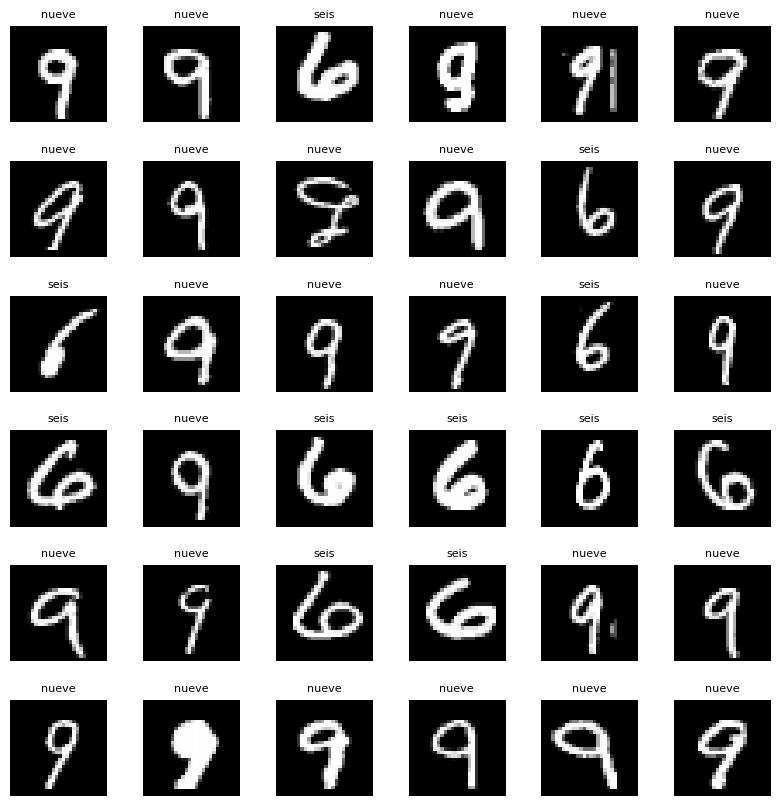

In [138]:
# visualization
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

labels = ['seis', 'nueve']
axes = axes.ravel() 
n_train = len(x_train_bin) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train_bin[index], cmap='gray')
    label_index = labels[int(y_train_sparse[index])]
    axes[i].set_title(label_index, fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [151]:
hparams = {
    'epochs': 30,
    'learning-rate': 0.001,
    'batch-size': 64,
    'val-split': 0.2,
    'loss': 'categorical_crossentropy'
}

op = Adam(hparams['learning-rate'])
final_sparsity = 0.3

model.compile(optimizer=op, loss=hparams['loss'], metrics=['accuracy'])
history_MNIST_bin = model.fit(
                    x_train_bin, y_train_cat,
                    validation_split=hparams['val-split'],
                    epochs=hparams['epochs'],
                    batch_size=hparams['batch-size'],
                    
)


Epoch 1/30
149/149 [==============================] - 2s 8ms/step - loss: 0.1019 - accuracy: 0.9801 - val_loss: 0.0150 - val_accuracy: 0.9962
Epoch 2/30
149/149 [==============================] - 1s 5ms/step - loss: 0.0124 - accuracy: 0.9980 - val_loss: 0.0093 - val_accuracy: 0.9971
Epoch 3/30
149/149 [==============================] - 1s 5ms/step - loss: 0.0084 - accuracy: 0.9983 - val_loss: 0.0065 - val_accuracy: 0.9983
Epoch 4/30
149/149 [==============================] - 1s 6ms/step - loss: 0.0058 - accuracy: 0.9987 - val_loss: 0.0054 - val_accuracy: 0.9992
Epoch 5/30
149/149 [==============================] - 0s 3ms/step - loss: 0.0048 - accuracy: 0.9989 - val_loss: 0.0051 - val_accuracy: 0.9992
Epoch 6/30
149/149 [==============================] - 1s 6ms/step - loss: 0.0038 - accuracy: 0.9989 - val_loss: 0.0051 - val_accuracy: 0.9983
Epoch 7/30
149/149 [==============================] - 1s 4ms/step - loss: 0.0029 - accuracy: 0.9994 - val_loss: 0.0052 - val_accuracy: 0.9987
Epoch 

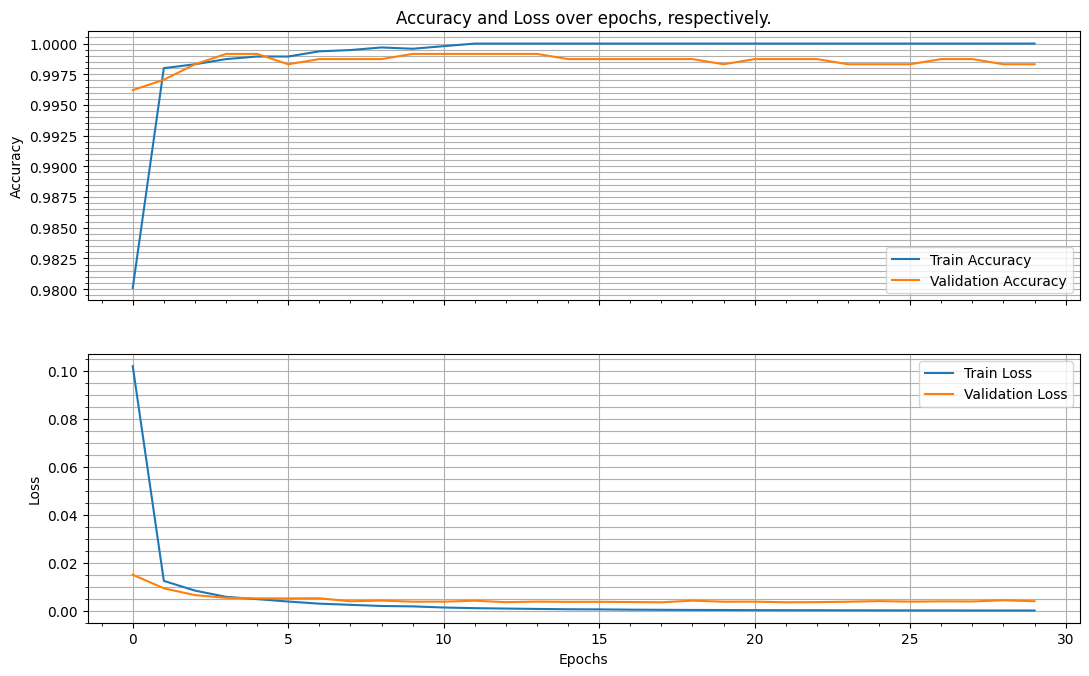

In [152]:
# Plot accuracy over epochs
fig_path = './figs/MNIST'

# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(history_MNIST_bin.history['accuracy'], label='Train Accuracy')
ax1.plot(history_MNIST_bin.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(history_MNIST_bin.history['loss'], label='Train Loss')
ax2.plot(history_MNIST_bin.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAT_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

62/62 [==============================] - 0s 973us/step - loss: 0.0121 - accuracy: 0.9969
Accuracy avg     0.9969


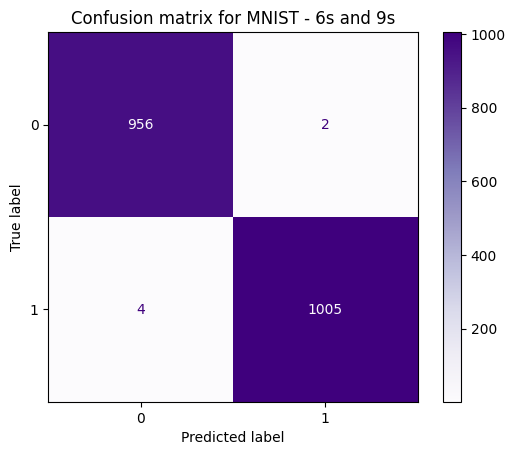

In [153]:
y_pred = model.predict(x_test_bin)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_cat, axis=1)


test_loss, test_acc = model.evaluate(x_test_bin, y_test_cat)

#report_classification = classification_report(y_test_cat, y_pred_labels, digits=4) #, output_dict=True
#print(report_classification)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for MNIST - 6s and 9s')
plt.show()

In [159]:
model.summary()
model.save('./models/MNIST-bin.h5')

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_14 (Flatten)        (None, 784)               0         
                                                                 
 dense_114 (Dense)           (None, 10)                7850      
                                                                 
 dense_115 (Dense)           (None, 2)                 22        
                                                                 
Total params: 7,872
Trainable params: 7,872
Non-trainable params: 0
_________________________________________________________________


In [155]:
# QAP

final_sparsity = 0.3

pruning_params = {
                'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=0, final_sparsity=final_sparsity, begin_step=0, end_step=3000
                )
            }

In [156]:
## Estrategia de cuantización

## Definición del número de bits para kernel, bias, y activación.
# 8-bits

kernelQ = "quantized_bits(8,4,alpha=1)"
biasQ = "quantized_bits(8, 4,alpha=1)"
activationQ = 'quantized_bits(8, 4)'

modelQ = Sequential(
            [   
                Flatten(input_shape=(28, 28)),
                QDense(10, name='fc3',
                        kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                        kernel_initializer='lecun_uniform'),
                QActivation(activation=activationQ, name='relu3'), 
                
                Dropout(0.1),
                
                QDense(n_classes, name='output',
                        kernel_quantizer= kernelQ, bias_quantizer= biasQ,
                        kernel_initializer='lecun_uniform'),
                Activation(activation='softmax', name='softmax')
               
            ],

            name="quantizedModel",
        )

/Users/denisegayet/.venv_py39/lib/python3.9/site-packages/keras/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [157]:
epochs = 16
lr = 0.001
loss = 'categorical_crossentropy'
op = Adam(lr)
metrics = ['accuracy']
batch = 64
val_split = 0.2


modelQAP = tfmot.sparsity.keras.prune_low_magnitude(modelQ, **pruning_params)

modelQAP.compile(optimizer=op, loss=loss, metrics=metrics)
                
historyQAP = modelQAP.fit(x_train_bin, y_train_cat,
                validation_split = val_split,
                epochs=epochs,
                batch_size = batch,
                callbacks = [tfmot.sparsity.keras.UpdatePruningStep()],
                verbose=1
                )

Epoch 1/16
149/149 [==============================] - 5s 9ms/step - loss: 0.2575 - accuracy: 0.9151 - val_loss: 0.0496 - val_accuracy: 0.9853
Epoch 2/16
149/149 [==============================] - 1s 6ms/step - loss: 0.0663 - accuracy: 0.9783 - val_loss: 0.0275 - val_accuracy: 0.9916
Epoch 3/16
149/149 [==============================] - 1s 4ms/step - loss: 0.0390 - accuracy: 0.9886 - val_loss: 0.0220 - val_accuracy: 0.9933
Epoch 4/16
149/149 [==============================] - 0s 3ms/step - loss: 0.0308 - accuracy: 0.9901 - val_loss: 0.0171 - val_accuracy: 0.9949
Epoch 5/16
149/149 [==============================] - 1s 4ms/step - loss: 0.0217 - accuracy: 0.9933 - val_loss: 0.0140 - val_accuracy: 0.9958
Epoch 6/16
149/149 [==============================] - 1s 6ms/step - loss: 0.0189 - accuracy: 0.9934 - val_loss: 0.0129 - val_accuracy: 0.9958
Epoch 7/16
149/149 [==============================] - 1s 4ms/step - loss: 0.0185 - accuracy: 0.9944 - val_loss: 0.0119 - val_accuracy: 0.9962
Epoch 

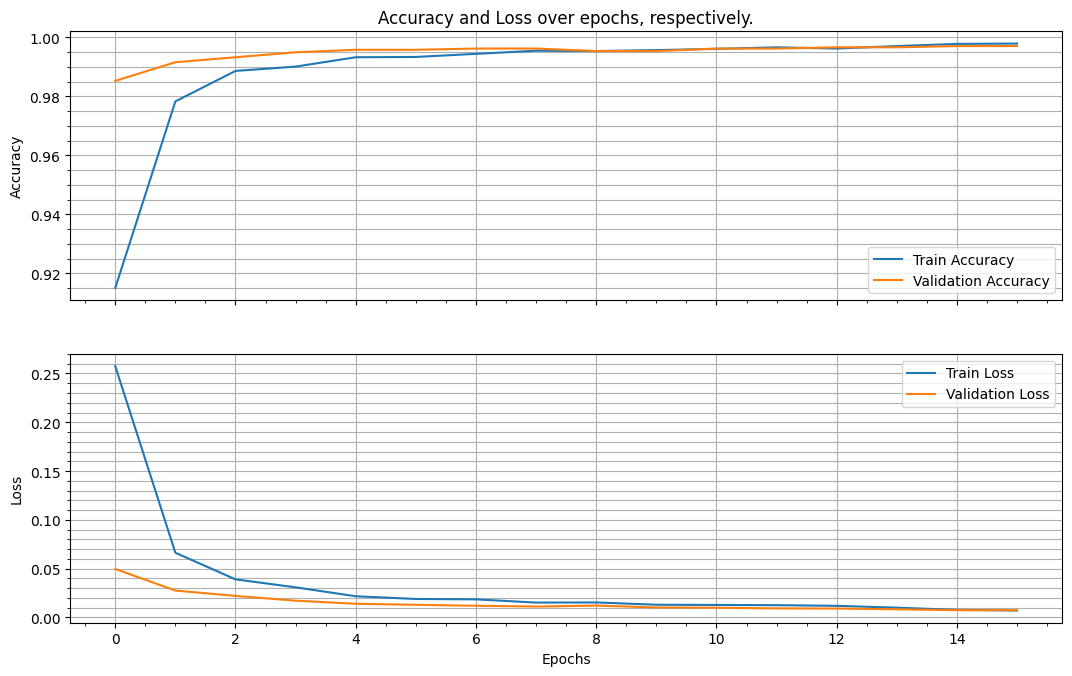

In [158]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyQAP.history['accuracy'], label='Train Accuracy')
ax1.plot(historyQAP.history['val_accuracy'], label='Validation Accuracy')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyQAP.history['loss'], label='Train Loss')
ax2.plot(historyQAP.history['val_loss'], label='Validation Loss')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

In [160]:
modelQAP.summary()
modelQAP = strip_pruning(modelQAP)
modelQAP.save('models/MNIST-bin_QAP.h5')

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_flatten  (None, 784)              1         
 _15 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_fc3 (Pr  (None, 10)               15692     
 uneLowMagnitude)                                                
                                                                 
 prune_low_magnitude_relu3 (  (None, 10)               1         
 PruneLowMagnitude)                                              
                                                                 
 prune_low_magnitude_dropout  (None, 10)               1         
 _11 (PruneLowMagnitude)                                         
                                                                 
 prune_low_magnitude_output   (None, 2)             

## QAT + DISTILLED KNOWDLEGE

In [158]:
# dataset loading
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

w = x_train_norm.shape[1]
h = x_train_norm.shape[2]

# classes
n_classes = 2
labels = [5, 7]

index = np.where((y_train == labels[0]) | (y_train == labels[1]))[0]
x_train_bin = x_train_norm[index]
y_train_bin = y_train[index]
y_train_bin[y_train_bin==labels[0]] = 0
y_train_bin[y_train_bin==labels[1]] = 1


index = np.where((y_test == labels[0]) | (y_test == labels[1]))[0]
x_test_bin = x_test_norm[index]
y_test_bin = y_test[index]
y_test_bin[y_test_bin==labels[0]] = 0
y_test_bin[y_test_bin==labels[1]] = 1


# one-hot encode labels
y_train_sparse = y_train_bin.copy()
y_train_cat = to_categorical(y_train_bin, num_classes = n_classes)
y_test_cat = to_categorical(y_test_bin, num_classes = n_classes)


Dataset input shape: 784

Output classes: 2


Text(0.5, 1.0, 'Class distribution in test set')

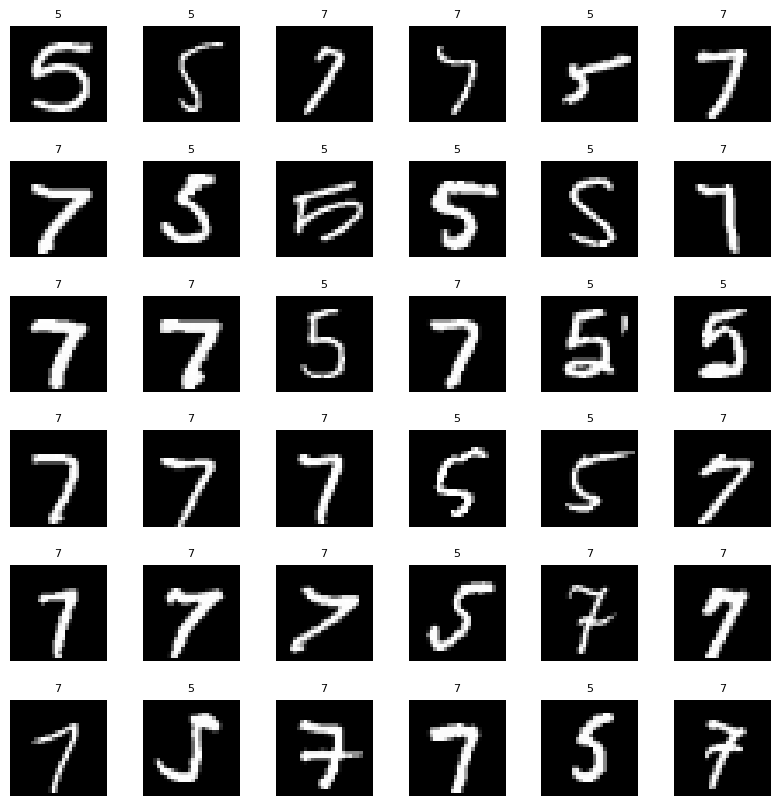

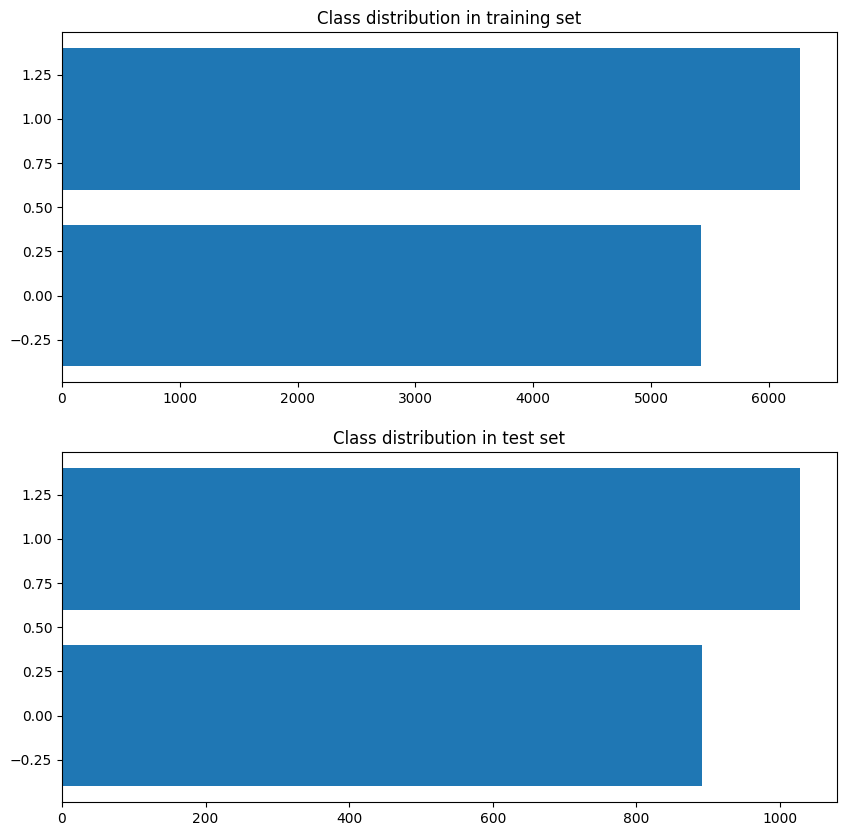

In [159]:
W_grid = 6
L_grid = 6
fig, axes = plt.subplots(L_grid, W_grid, figsize = (10,10))

axes = axes.ravel() 
n_train = len(x_train_bin) 

for i in np.arange(0, W_grid * L_grid): 

    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index    
    axes[i].imshow(x_train_bin[index], cmap='gray')
    label_index = labels[int(y_train_sparse[index])]
    axes[i].set_title(label_index, fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

x_train_bin = x_train_bin.reshape(-1, 28 * 28)                       # Aplanar imágenes
x_test_bin = x_test_bin.reshape(-1, 28 * 28)

in_shape = x_train_bin[0].shape[0]

print(f"\nDataset input shape: {in_shape}")
print(f"\nOutput classes: {n_classes}")

fig, axes = plt.subplots(2, 1, figsize = (10,10))
axes = axes.ravel()

classes, counts = np.unique(y_train_bin, return_counts=True)
axes[0].barh(classes, counts)
axes[0].set_title('Class distribution in training set')

classes, counts = np.unique(y_test_bin, return_counts=True)
axes[1].barh(classes, counts)
axes[1].set_title('Class distribution in test set')

In [242]:
## QAT + Knowledge Dest.


# Estrategia de cuantizacion

# Definicion del numer de bits para kernel, bias, y activacion. 
# 8 bits

m = 8
d = 4

kernelQ = f'quantized_bits({m},{d},alpha=1)'
biasQ = f'quantized_bits({m},{d},alpha=1)'
activationQ = f'quantized_bits({m},{d})'

def build_teacher():
    model = Sequential([
    QDense(32, name='fc1',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu1'), 
    Dropout(0.4),
        
    QDense(20, name='fc2',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu2'), 
    Dropout(0.4),

    QDense(10, name='fc3',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu3'), 
    Dropout(0.4),
    
    QDense(10, name='fc4',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu4'), 
    Dropout(0.4),
    
    QDense(n_classes, name='output',
            kernel_quantizer= kernelQ, bias_quantizer= biasQ,
            kernel_initializer='lecun_uniform'),
    Activation(activation='softmax', name='softmax')
],
name="quantizedModel",
)
    return model

def build_student():
    model = Sequential([
    QDense(5, name='fc1',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu1'), 
    Dropout(0.3),

    QDense(5, name='fc2',
            kernel_quantizer=kernelQ, bias_quantizer=biasQ,
            kernel_initializer='lecun_uniform', input_shape=(28 * 28,)),
    QActivation(activation=activationQ, name='relu2'), 
    Dropout(0.3),
    
    QDense(n_classes, name='output',
            kernel_quantizer= kernelQ, bias_quantizer= biasQ,
            kernel_initializer='lecun_uniform'),
    Activation(activation='softmax', name='softmax')
],
name="quantizedModel",
)
    return model

In [243]:
# Definir el modelo Teacher (MLP grande) 
hparamsT = {
    'batch-size' : 64,
    'epochs' : 32,
    'learning-rate' : 0.001,
    'weight_decay' : 0.004
}



# Compilar y entrenar el modelo Teacher
teacher = build_teacher()
teacher.summary()

teacher.compile(optimizer=Adam(learning_rate=hparamsT['learning-rate'], weight_decay=hparamsT['weight_decay']), 
                loss="categorical_crossentropy", 
                metrics=["accuracy"])
historyT = teacher.fit(x_train_bin, y_train_cat,
                       epochs=hparamsT['epochs'],
                       batch_size=hparamsT['batch-size'],
                       validation_data=(x_test_bin, y_test_cat))

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 32)                25120     
                                                                 
 relu1 (QActivation)         (None, 32)                0         
                                                                 
 dropout_137 (Dropout)       (None, 32)                0         
                                                                 
 fc2 (QDense)                (None, 20)                660       
                                                                 
 relu2 (QActivation)         (None, 20)                0         
                                                                 
 dropout_138 (Dropout)       (None, 20)                0         
                                                                 
 fc3 (QDense)                (None, 10)             

/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer LecunUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Epoch 1/32
183/183 [==============================] - 1s 2ms/step - loss: 1.9462 - accuracy: 0.6278 - val_loss: 0.1505 - val_accuracy: 0.9391
Epoch 2/32
183/183 [==============================] - 0s 847us/step - loss: 0.4615 - accuracy: 0.8386 - val_loss: 0.0813 - val_accuracy: 0.9651
Epoch 3/32
183/183 [==============================] - 0s 919us/step - loss: 0.2210 - accuracy: 0.9225 - val_loss: 0.0687 - val_accuracy: 0.9776
Epoch 4/32
183/183 [==============================] - 0s 940us/step - loss: 0.1595 - accuracy: 0.9451 - val_loss: 0.0591 - val_accuracy: 0.9823
Epoch 5/32
183/183 [==============================] - 0s 910us/step - loss: 0.1344 - accuracy: 0.9592 - val_loss: 0.0570 - val_accuracy: 0.9865
Epoch 6/32
183/183 [==============================] - 0s 924us/step - loss: 0.1117 - accuracy: 0.9663 - val_loss: 0.0517 - val_accuracy: 0.9875
Epoch 7/32
183/183 [==============================] - 0s 865us/step - loss: 0.0964 - accuracy: 0.9711 - val_loss: 0.0558 - val_accuracy: 0

In [244]:
student = build_student()
train_labels = np.argmax(y_train_cat, axis=1)

distilledMLP = Distiller(student=student, teacher=teacher)

In [245]:
distilledMLP.student.summary()

Model: "quantizedModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 5)                 3925      
                                                                 
 relu1 (QActivation)         (None, 5)                 0         
                                                                 
 dropout_141 (Dropout)       (None, 5)                 0         
                                                                 
 fc2 (QDense)                (None, 5)                 30        
                                                                 
 relu2 (QActivation)         (None, 5)                 0         
                                                                 
 dropout_142 (Dropout)       (None, 5)                 0         
                                                                 
 output (QDense)             (None, 2)              

In [246]:
hparamsS = {
    'epochs' : 64,
    'batch-size' : 64,
    'learning-rate' : 0.001,
    'weight-decay' : 0.004,
    'val-split' : 0.2,
}

adam = Adam(hparamsS['learning-rate'], weight_decay=hparamsS['weight-decay'])
distilledMLP.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

historyS = distilledMLP.fit(x_train_bin, train_labels, 
                           validation_split=hparamsS['val-split'],
                           batch_size = hparamsS['batch-size'], 
                           epochs= hparamsS['epochs'])

Epoch 1/64


/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/backend.py:5714: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


147/147 [==============================] - 1s 2ms/step - sparse_categorical_accuracy: 0.6698 - student_loss: 3.7737 - distillation_loss: 0.0015 - val_sparse_categorical_accuracy: 0.8225 - val_student_loss: 0.4754
Epoch 2/64
147/147 [==============================] - 0s 1ms/step - sparse_categorical_accuracy: 0.8096 - student_loss: 1.0242 - distillation_loss: 7.7432e-04 - val_sparse_categorical_accuracy: 0.9110 - val_student_loss: 0.0134
Epoch 3/64
147/147 [==============================] - 0s 905us/step - sparse_categorical_accuracy: 0.8714 - student_loss: 0.5910 - distillation_loss: 5.1332e-04 - val_sparse_categorical_accuracy: 0.9405 - val_student_loss: 0.0035
Epoch 4/64
147/147 [==============================] - 0s 956us/step - sparse_categorical_accuracy: 0.9071 - student_loss: 0.3550 - distillation_loss: 3.5079e-04 - val_sparse_categorical_accuracy: 0.9607 - val_student_loss: 0.0021
Epoch 5/64
147/147 [==============================] - 0s 1ms/step - sparse_categorical_accuracy: 0.

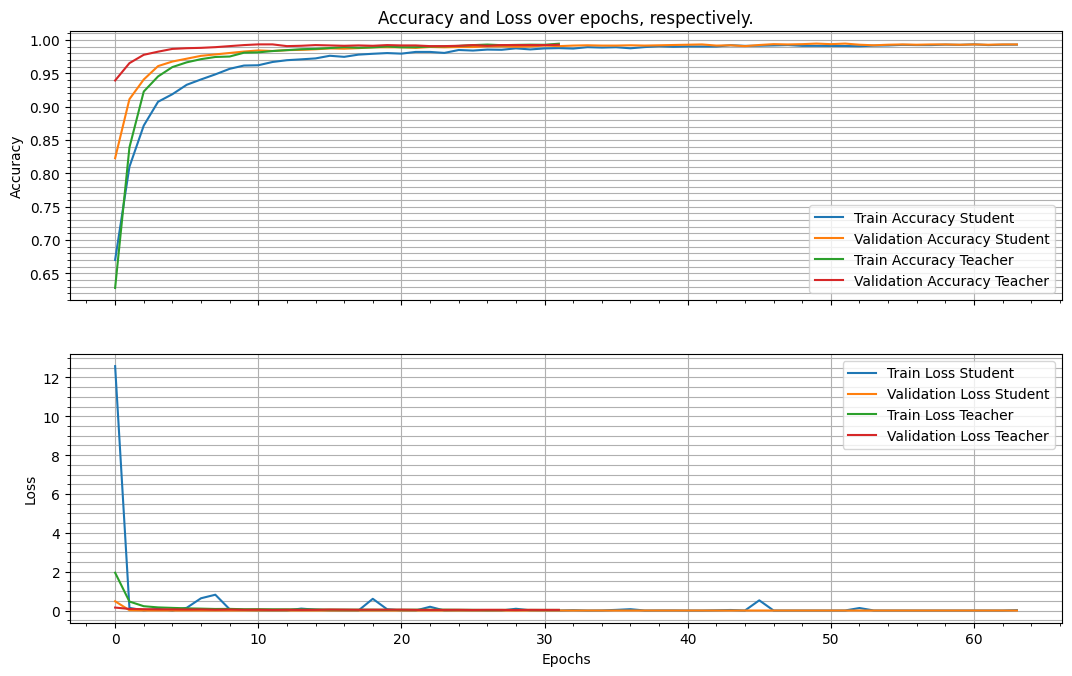

In [247]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyS.history['sparse_categorical_accuracy'], label='Train Accuracy Student')
ax1.plot(historyS.history['val_sparse_categorical_accuracy'], label='Validation Accuracy Student')
ax1.plot(historyT.history['accuracy'], label='Train Accuracy Teacher')
ax1.plot(historyT.history['val_accuracy'], label='Validation Accuracy Teacher')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyS.history['student_loss'], label='Train Loss Student')
ax2.plot(historyS.history['val_student_loss'], label='Validation Loss Student')
ax2.plot(historyT.history['loss'], label='Train Loss Teacher')
ax2.plot(historyT.history['val_loss'], label='Validation Loss Teacher')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

In [119]:
distilledMLP.student.save("models/MNIST_bin_QAT_KD_st_6_3.h5")
teacher.save('models/MNIST_bin_QAT_KD_t_6_3.h5')

/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


60/60 [==============================] - 0s 479us/step
[[4.8400775e-08 1.0000000e+00]
 [9.9999976e-01 2.2033312e-07]
 [1.0000000e+00 5.7477344e-08]
 ...
 [1.0000000e+00 4.6184343e-08]
 [4.5468319e-08 1.0000000e+00]
 [1.0000000e+00 4.7650392e-08]]
60/60 [==============================] - 0s 573us/step - loss: 0.0327 - accuracy: 0.9927
Accuracy avg     0.9927


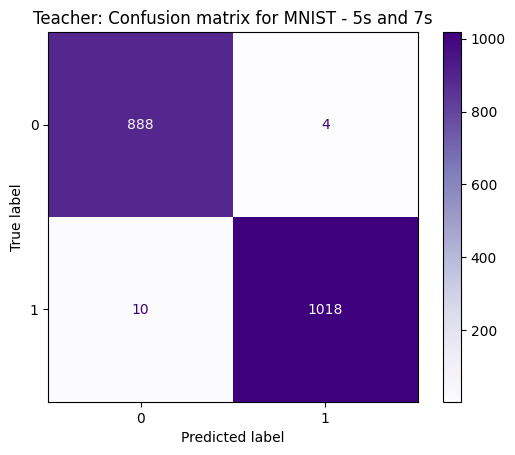

tf.Tensor(
[[1.1861120e-08 1.0000000e+00]
 [9.9998021e-01 1.9833367e-05]
 [1.0000000e+00 1.4845932e-09]
 ...
 [1.0000000e+00 3.3647407e-10]
 [3.0161343e-10 1.0000000e+00]
 [1.0000000e+00 3.0636316e-10]], shape=(1920, 2), dtype=float32)
60/60 [==============================] - 0s 741us/step - loss: 0.0327 - accuracy: 0.9927
Accuracy avg     0.9927


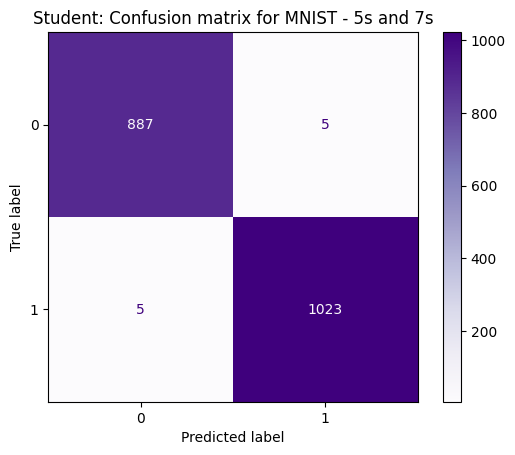

In [248]:
y_pred = teacher.predict(x_test_bin)
print(y_pred)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_cat, axis=1)


test_loss, test_acc = teacher.evaluate(x_test_bin, y_test_cat)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Teacher: Confusion matrix for MNIST - 5s and 7s')
plt.show()


y_pred = distilledMLP.student(x_test_bin)
print(y_pred)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_cat, axis=1)


test_loss, test_acc = teacher.evaluate(x_test_bin, y_test_cat)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Student: Confusion matrix for MNIST - 5s and 7s')
plt.show()

[ 0.09460759  0.42402053  0.90188575 ...  0.17898501 -0.03061956
  0.03061775]


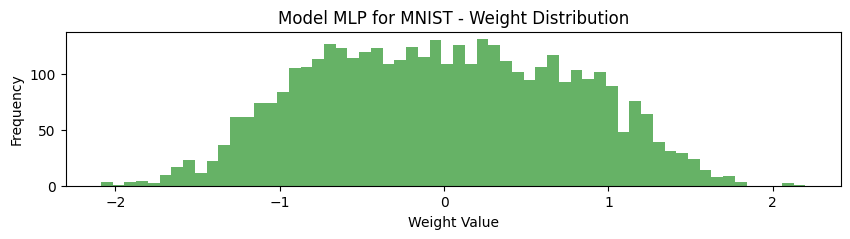

the exponent is the minimum number of digits to difference two different weigths


In [249]:

weights = np.concatenate([w.flatten() for w in distilledMLP.student.get_weights()])
print(weights)

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for MNIST - Weight Distribution")
plt.show()

min_diff = 1

# for i in range(1, len(weights)):

#     wvec = weights[i]*np.ones(i)

#     diffvec = np.abs(weights[0:i]-wvec)
    
#     new_diffvec = [item for item in diffvec if item != 0]

#     new_min_diff = np.min(new_diffvec)
#     if min_diff > new_min_diff:
#         min_diff = new_min_diff
#         print(new_min_diff)

# print(min_diff, '\n')

print("the exponent is the minimum number of digits to difference two different weigths")

PASOS:

Agrego capas. Mejor accuracy.
Agrego neuronas. No mejor accuracy, pero no convirgio. Entonces. aumento epochs.


In [250]:
# Prunning : 
final_sparsity = 0.7

pruning_params={
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=3000
    )
}

studentP = tfmot.sparsity.keras.prune_low_magnitude(distilledMLP.student, **pruning_params)
studentP.compile(optimizer=adam, loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
                 metrics=[keras.metrics.SparseCategoricalAccuracy()])

history = studentP.fit(
                    x_train_bin, train_labels,
                    validation_split=hparamsS['val-split'],
                    epochs=hparamsS['epochs'],
                    batch_size=hparamsS['batch-size'],
                    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
                    verbose=1
)

Epoch 1/64


/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/backend.py:5714: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


147/147 [==============================] - 1s 2ms/step - loss: 0.0213 - sparse_categorical_accuracy: 0.9924 - val_loss: 0.0297 - val_sparse_categorical_accuracy: 0.9923
Epoch 2/64
147/147 [==============================] - 0s 828us/step - loss: 0.0210 - sparse_categorical_accuracy: 0.9940 - val_loss: 0.0267 - val_sparse_categorical_accuracy: 0.9936
Epoch 3/64
147/147 [==============================] - 0s 812us/step - loss: 0.0238 - sparse_categorical_accuracy: 0.9911 - val_loss: 0.0270 - val_sparse_categorical_accuracy: 0.9923
Epoch 4/64
147/147 [==============================] - 0s 812us/step - loss: 0.0219 - sparse_categorical_accuracy: 0.9925 - val_loss: 0.0293 - val_sparse_categorical_accuracy: 0.9940
Epoch 5/64
147/147 [==============================] - 0s 840us/step - loss: 0.0217 - sparse_categorical_accuracy: 0.9908 - val_loss: 0.0344 - val_sparse_categorical_accuracy: 0.9927
Epoch 6/64
147/147 [==============================] - 0s 829us/step - loss: 0.0227 - sparse_categorical

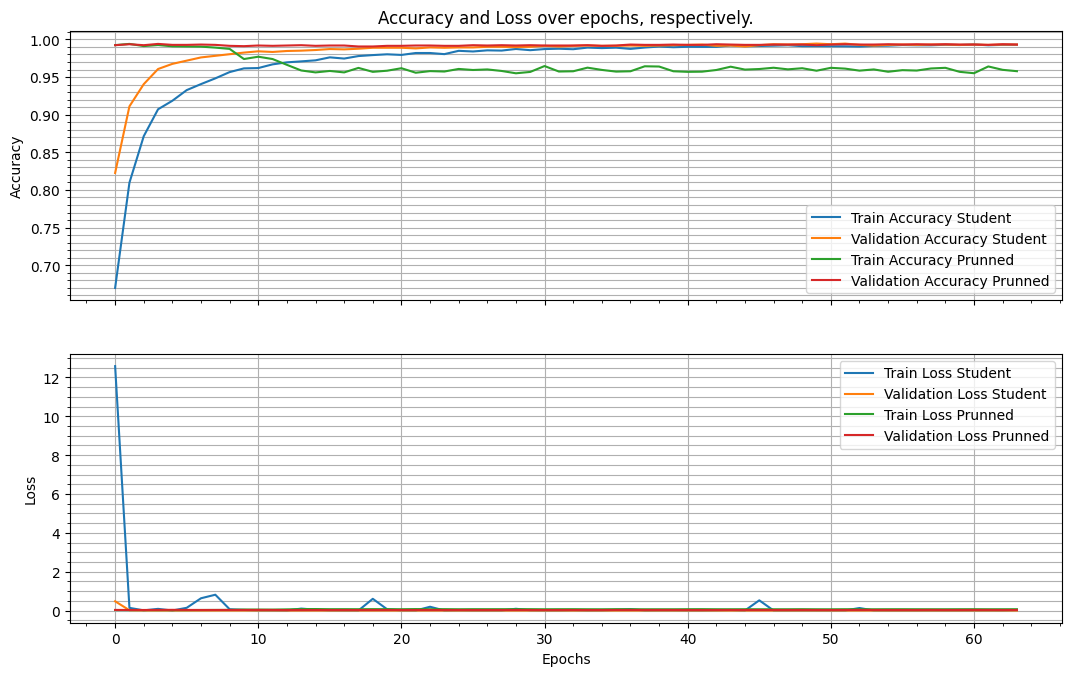

In [251]:
# Plot accuracy and loss over epochs
ax1 = plt.subplot(211)
ax1.plot(historyS.history['sparse_categorical_accuracy'], label='Train Accuracy Student')
ax1.plot(historyS.history['val_sparse_categorical_accuracy'], label='Validation Accuracy Student')
ax1.plot(history.history['sparse_categorical_accuracy'], label='Train Accuracy Prunned')
ax1.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy Prunned')
ax1.minorticks_on()
ax1.tick_params('x', labelbottom=False)
ax1.grid(visible=True, which='both', axis='y')
ax1.grid(visible=True, which='Major', axis='x')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy and Loss over epochs, respectively.')
ax1.legend()

ax2 = plt.subplot(212)
ax2.plot(historyS.history['student_loss'], label='Train Loss Student')
ax2.plot(historyS.history['val_student_loss'], label='Validation Loss Student')
ax2.plot(history.history['loss'], label='Train Loss Prunned')
ax2.plot(history.history['val_loss'], label='Validation Loss Prunned')
ax2.minorticks_on()
ax2.grid(visible=True, which='both', axis='y')
ax2.grid(visible=True, which='Major', axis='x')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

fig = plt.gcf()
fig.set_size_inches(1280/fig.dpi, 768/fig.dpi)
#plt.savefig("../img/Compression_QAP_6bit_3bit_acc_n_loss_iter-" + str(iter) + ".png", bbox_inches='tight')

plt.show()

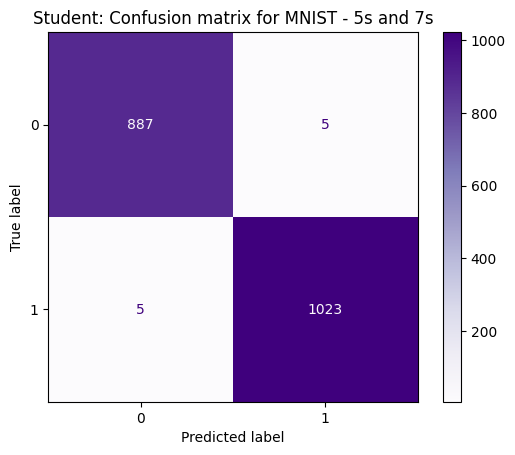

60/60 [==============================] - 0s 510us/step
[[1.1317960e-08 1.0000000e+00]
 [1.0000000e+00 4.4069406e-08]
 [1.0000000e+00 3.6022588e-11]
 ...
 [1.0000000e+00 1.7185414e-10]
 [4.4135796e-11 1.0000000e+00]
 [1.0000000e+00 6.2241441e-11]]
60/60 [==============================] - 0s 581us/step - loss: 0.0327 - accuracy: 0.9927
Accuracy avg     0.9927


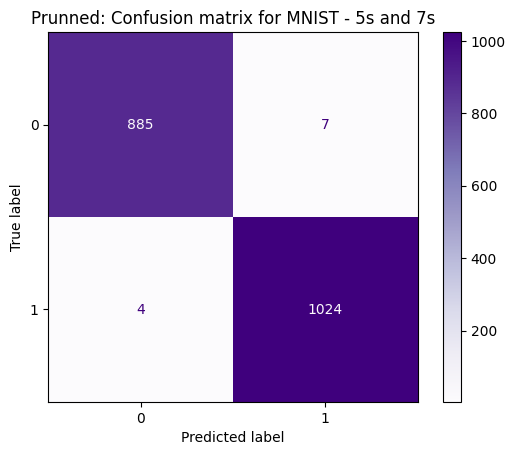

In [252]:
cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Student: Confusion matrix for MNIST - 5s and 7s')
plt.show()


y_pred = studentP.predict(x_test_bin)
print(y_pred)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_cat, axis=1)


test_loss, test_acc = teacher.evaluate(x_test_bin, y_test_cat)

print('Accuracy avg     %.4f' % test_acc)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Prunned: Confusion matrix for MNIST - 5s and 7s')
plt.show()


In [253]:
studentP = strip_pruning(studentP)
studentP.save('models/mnist_bin_QAT_KD_P_st.h5')

/Users/denisegayet/.venv_py39_test/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


[ 0.          0.          0.90188575 ...  0.         -0.06376528
  0.0637624 ]


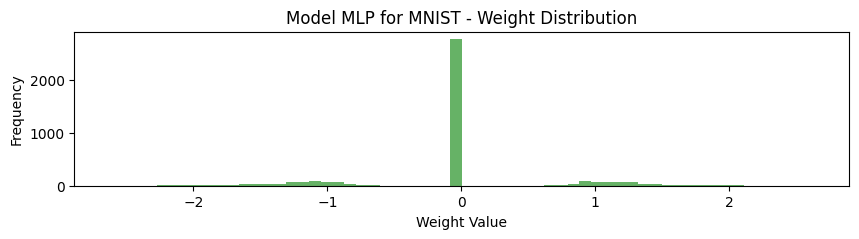

In [254]:
weights = np.concatenate([w.flatten() for w in studentP.get_weights()])
print(weights)

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for MNIST - Weight Distribution")
plt.show()

min_diff = 1